In [1]:
import pandas as pd

df = pd.read_excel("../data/ABNCleanexcel_data.xlsx")

In [2]:
df = df[[
    "price",
    "availability_365",
    "minimum_nights",
    "room_type",
    "city",
    "calculated_host_listings_count",
    "reviews_per_month",
    "number_of_reviews_ltm"
]]

In [3]:
df.fillna(0, inplace=True)

,price,availability_365,minimum_nights,room_type,city,calculated_host_listings_count,reviews_per_month,number_of_reviews_ltm
0,202,128,2,Entire home/apt,San Francisco,1,2.31,59
1,235,365,30,Entire home/apt,San Francisco,1,0.66,0
2,56,365,32,Private room,San Francisco,13,0.09,1
3,575,365,9,Entire home/apt,San Francisco,2,0.17,0
4,110,159,1,Private room,San Francisco,2,4.65,34
...,...,...,...,...,...,...,...,...
229801,389,365,2,Entire home/apt,San Mateo County,1,1.00,0
229802,158,364,1,Entire home/apt,San Mateo County,1,1.00,0
229803,97,359,1,Entire home/apt,San Mateo County,32,1.00,0
229804,62,67,2,Private room,San Mateo County,3,1.00,0


In [7]:
#Encode Categorical Columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["room_type"] = le.fit_transform(df["room_type"])
df["city"] = le.fit_transform(df["city"])

In [5]:
#Features & Target
X = df.drop("number_of_reviews_ltm", axis=1)

y = df["number_of_reviews_ltm"]

In [6]:
# Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [8]:
#Train Random Forest Model

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [9]:
# pridication 

pred = rf.predict(X_test)


In [10]:
# Evaluate Model

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, pred)))

print("R2 Score :", r2_score(y_test, pred))

MAE : 4.693435388543422
RMSE : 9.538053006359043
R2 Score : 0.7558348337568392


In [16]:
# Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                          Feature  Importance
6               reviews_per_month    0.813549
1                availability_365    0.055481
0                           price    0.051997
4                            city    0.028419
5  calculated_host_listings_count    0.025294
2                  minimum_nights    0.018207
3                       room_type    0.007053


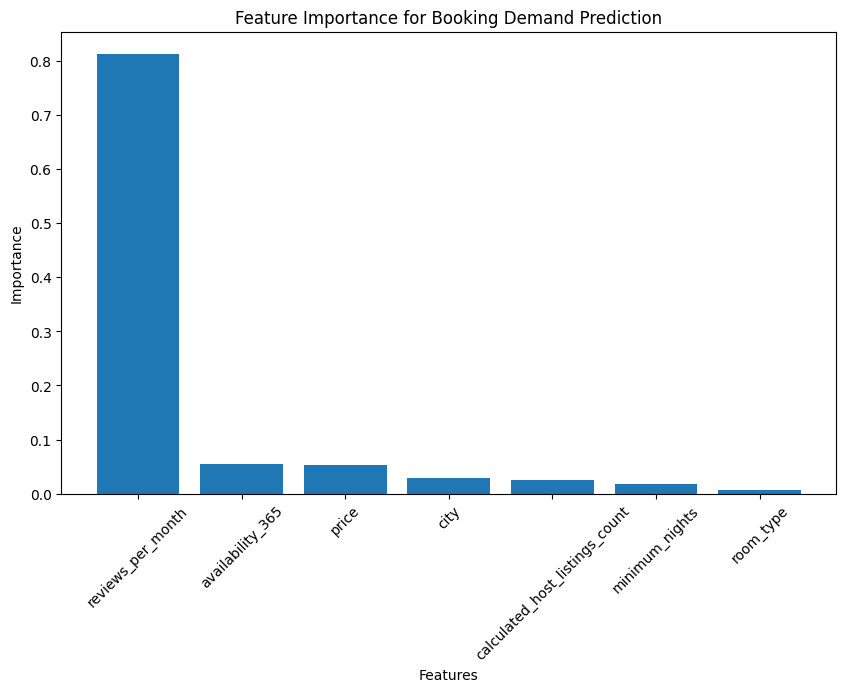

In [17]:
# Plot Feature Importance

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)

plt.title("Feature Importance for Booking Demand Prediction")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.show()

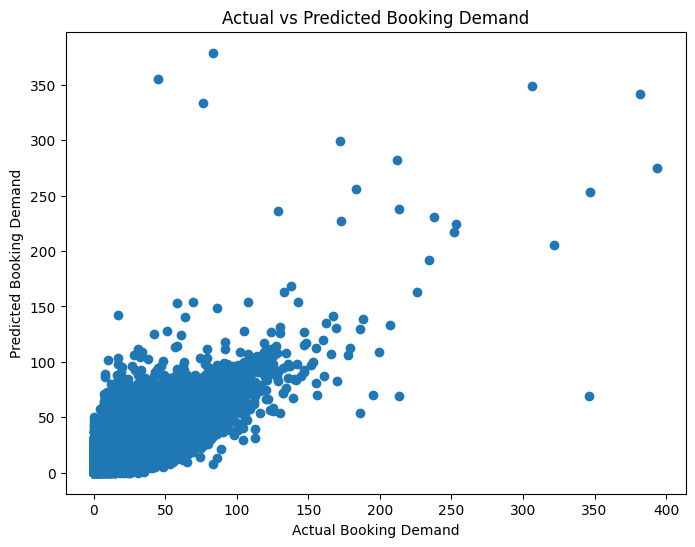

In [18]:
#Actual vs Predicted Plot

plt.figure(figsize=(8,6))

plt.scatter(y_test, pred)

plt.xlabel("Actual Booking Demand")

plt.ylabel("Predicted Booking Demand")

plt.title("Actual vs Predicted Booking Demand")

plt.show()

In [19]:
import joblib

joblib.dump(rf, "../models/booking_demand_model.pkl")

print("Booking Demand Model Saved Successfully")

Booking Demand Model Saved Successfully


In [20]:
import joblib

joblib.dump(rf, "../models/price_prediction_model.pkl")

print("Price Prediction Model Saved Successfully")

Price Prediction Model Saved Successfully
